In [1]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from ydata_profiling import ProfileReport

from sklearn.ensemble import RandomForestClassifier as RF
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, mean_squared_error
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report
from sklearn.utils import resample
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier, Pool
import optuna
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')
    


In [2]:
df = pd.read_parquet('data/creditcard.parquet')

df.shape

(284807, 31)

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

# Data Overview

In [4]:
print(f"Nulls: {df.isnull().sum().sum()}")

Nulls: 0


In [6]:
# Class balance
fraud_count     = df['Class'].sum()
non_fraud_count = len(df) - fraud_count
print(f"Non-Fraud  : {non_fraud_count:,} ({non_fraud_count/len(df)*100:.2f}%)")
print(f"Fraud      : {fraud_count:,}     ({fraud_count/len(df)*100:.2f}%)")
print(f"Imbalance ratio : 1 fraud per {non_fraud_count//fraud_count} legitimate transactions")


Non-Fraud  : 284,315 (99.83%)
Fraud      : 492     (0.17%)
Imbalance ratio : 1 fraud per 577 legitimate transactions


In [10]:
# Time range
print(f"Min Time : {df['Time'].min():.0f}s")
print(f"Max Time : {df['Time'].max():.0f}s  ({df['Time'].max()/3600:.1f} hours of data)")


Min Time : 0s
Max Time : 172792s  (48.0 hours of data)


In [8]:
print(f"Duplicates : {df.duplicated().sum():,}")

Duplicates : 1,081


In [9]:
# Investigate Duplicates
dupes = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

print(f"Total duplicate rows : {df.duplicated().sum():,}")
print(f"Total rows involved  : {len(dupes):,}")

Total duplicate rows : 1,081
Total rows involved  : 1,854


In [11]:
# Class breakdown of duplicates
print(dupes['Class'].value_counts().to_string())

#  amount range in duplicates 
print(f"Min: ${dupes['Amount'].min():.2f}  |  Max: ${dupes['Amount'].max():.2f}  |  Mean: ${dupes['Amount'].mean():.2f}")


Class
0    1822
1      32
Min: $0.00  |  Max: $1848.06  |  Mean: $60.09


In [12]:
print(dupes.head(10)[['Time', 'Amount', 'Class']].to_string())

      Time  Amount  Class
34    26.0    1.77      0
35    26.0    1.77      0
32    26.0    6.14      0
33    26.0    6.14      0
112   74.0    1.18      0
113   74.0    1.18      0
114   74.0    1.18      0
115   74.0    1.18      0
220  145.0    6.00      0
221  145.0    6.00      0


In [13]:
# Are duplicates clustered in time?
print(f"Min Time: {dupes['Time'].min():.0f}s  |  Max Time: {dupes['Time'].max():.0f}s")


Min Time: 26s  |  Max Time: 172233s


In [14]:
# How many are exact full-row duplicates?
exact = df.duplicated(keep=False)
print(f"Rows that are 100% identical across all 31 columns: {exact.sum():,}")

Rows that are 100% identical across all 31 columns: 1,854


Decision: I will Drop the duplicate

- 1,854 rows are 100% identical across all 31 columns, including V1-V28 PCA features. Real transactions happening at the same second would never produce identical PCA transformations. These are data artifacts, not real events.
- Only 32 are fraud, dropping them won't meaningfully hurt the fraud signal.
- Keeping them would artificially inflate model confidence on repeated patterns.

In [15]:
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Original rows : {len(df):,}")
print(f"Cleaned rows: {len(df_clean):,}")
print(f"Rows removed: {len(df) - len(df_clean):,}")

Original rows : 284,807
Cleaned rows: 283,726
Rows removed: 1,081


In [17]:
# class balance after removing duplicates
fraud_count     = df_clean['Class'].sum()
non_fraud_count = len(df_clean) - fraud_count
print(f"Non-Fraud : {non_fraud_count:,} ({non_fraud_count/len(df_clean)*100:.2f}%)")
print(f"Fraud     : {fraud_count:,}     ({fraud_count/len(df_clean)*100:.2f}%)")
print(f"Imbalance ratio : 1 fraud per {non_fraud_count//fraud_count:,} legitimate transactions")


Non-Fraud : 283,253 (99.83%)
Fraud     : 473     (0.17%)
Imbalance ratio : 1 fraud per 598 legitimate transactions


Extreme imbalance means accuracy is meaningless as a metric. A model predicting "no fraud" every time would score 99.83% accuracy. 

We will optimize for **Precision, Recall and F1 on the fraud class**

In [16]:
df = df_clean.copy()

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


# Observations

- We see that the data is very highly imbalanced, only 0.17% are fraud class.
- Since the varibales don't have names, it's hard to make conlcusions based on their meaning.
- The distributions of the features vary. Some of them close to normal, but some of them have strong skewness and maybe outliers.
- One big problem in terms of features can be identifying if the outlying values are outliers or not. This is the most important step for baseline modeling.
- Since the features are not strongly correlated to each other but some of them have high positive and negative correlations. So, multicollinearity should not be a big problem and depending on the influence on the taget, many features can be good predictors.

KDE: All Features vs Class

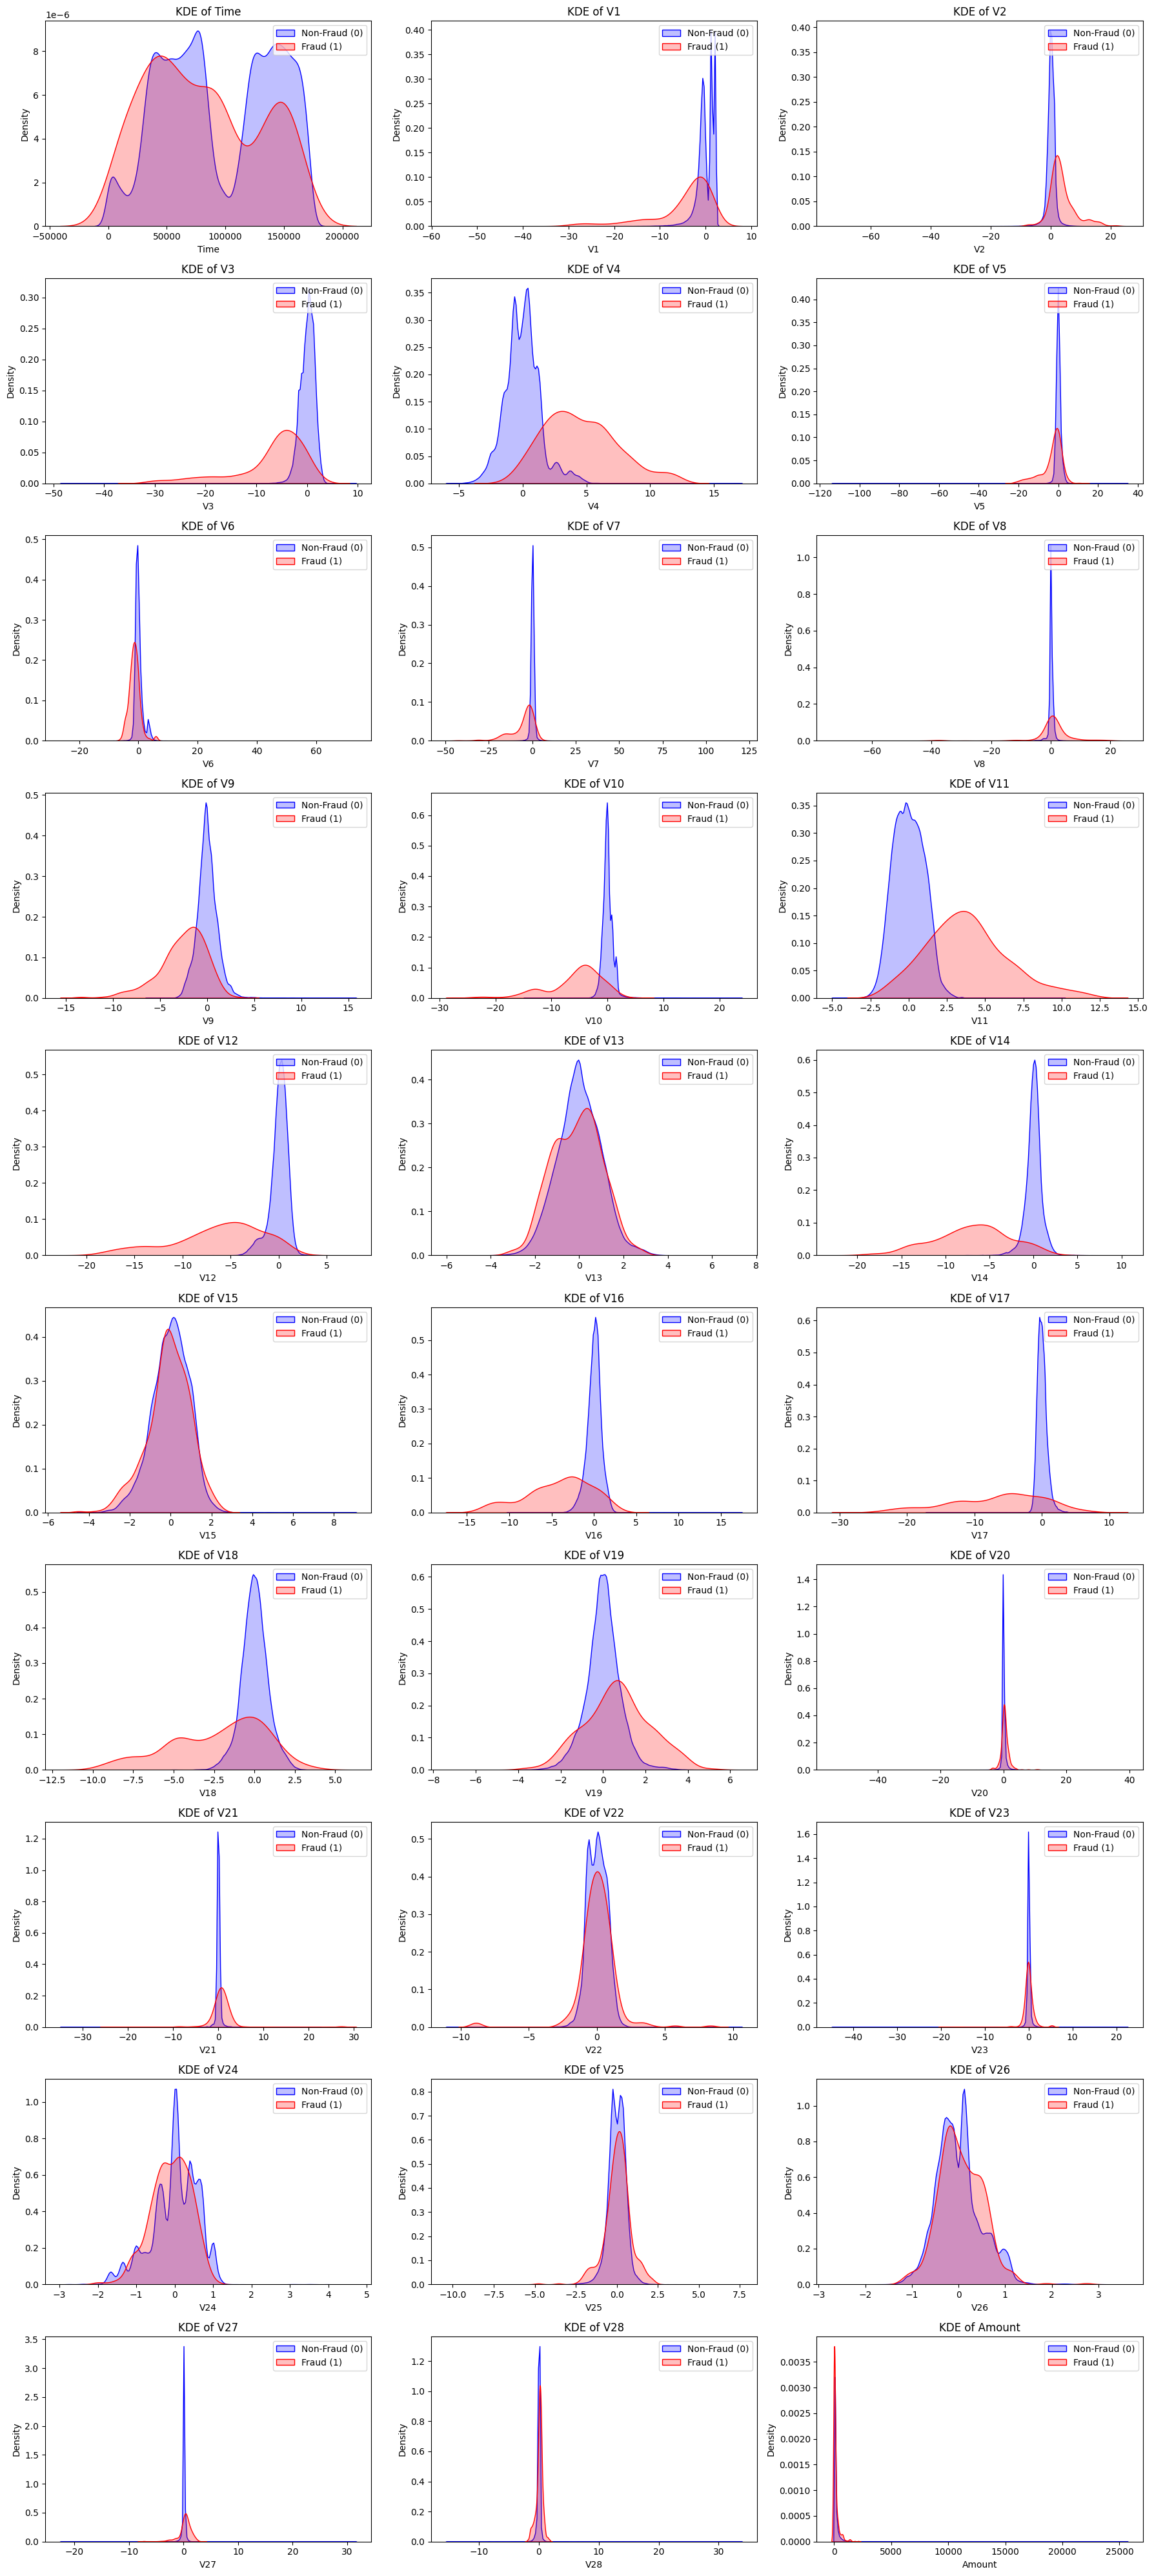

In [21]:
features = [col for col in df.columns if col != 'Class']

# Split fraud and non-fraud
fraud = df[df['Class'] == 1]
non_fraud = df[df['Class'] == 0]

# Number of subplots
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols  # ceiling division

# Set up the plot
plt.figure(figsize=(6 * n_cols, 4 * n_rows))

# Plot KDEs
for i, feat in enumerate(features):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    sns.kdeplot(non_fraud[feat], label='Non-Fraud (0)', color='blue', fill=True, common_norm=False)
    sns.kdeplot(fraud[feat], label='Fraud (1)', color='red', fill=True, common_norm=False)
    ax.set_title(f'KDE of {feat}')
    ax.legend()

plt.tight_layout()

**1. Most Discriminative Features**

The following features show strong separation between fraud and non-fraud distributions:

- V4, V10, V12, 14, V16, V17

Fraud distributions are shifted or have distinct peaks compared to non-fraud. Some of them also have longer tails, especially on the left (e.g., V10, V12, V14).

**2. Moderately Informative Features**

These features show partial overlap between the two classes but still contain useful signals:

- V3, V7, V9, V11, V18, V19, V23, V26

For example, V9 and V11 have longer right tails in the fraud class, while V18 and V26 are visibly skewed. These features may benefit from scaling or interaction with others.

**3. Low-Predictive Features**

These features have almost identical distributions between fraud and non-fraud:

- V13, V15, V20, V21, V22, V25, V2, V28

Their KDE plots overlap almost entirely. Some (like V21, V25, V27) show very sharp spikes and may contain extreme outliers.

**4. Amount Feature**

It's hard to make conclusions from this plot.

**5. Time Feature**

Peaks in fraud activity occur at different times compared to non-fraud.

Suggest extracting time-based features such as hour of day, day of week, or night/weekend indicators.

Time may reflect behavioral patterns of fraudulent activity.

**Outlier Cleaning Suggestions**

- Most of the variables have very heavy tails which means those values might be outliers. This can significantly impact the model, so we need to consider removing them.

Preprocessing

Outlier Removal

In [ ]:
sigma_threshold = 5

features = [col for col in df.columns if col != 'Class']


In [24]:
for feat in features:
    std = df[feat].std()
    df = df[
        (df[feat] < df[feat].mean() + sigma_threshold * std) & (df[feat] > df[feat].mean() - sigma_threshold * std)
        ]

In [21]:
print(f'{(df.shape[0] - df_no_outliers.shape[0]) / df.shape[0] * 100 } % data points are removed')
print(f"{df_no_outliers[df_no_outliers['Class'] == 1].shape[0]} number of fraud transactions in the cleaned dataset")
print(f"{df[df['Class'] == 1].shape[0]} number of fraud transactions in the original dataset")

NameError: name 'df_no_outliers' is not defined

In [11]:
print(f'{(df.shape[0] - df_clean.shape[0]) / df.shape[0] * 100 } % data points are removed')

6.3102381612811485 % data points are removed


In [12]:
print(f"{df_clean[df_clean['Class'] == 1].shape[0]} number of fraud transactions in the cleaned dataset")
print(f"{df[df['Class'] == 1].shape[0]} number of fraud transactions in the original dataset")

63 number of fraud transactions in the cleaned dataset
492 number of fraud transactions in the original dataset


We see that even with high sigma threshold, we removed a lot of fraud class transactions.

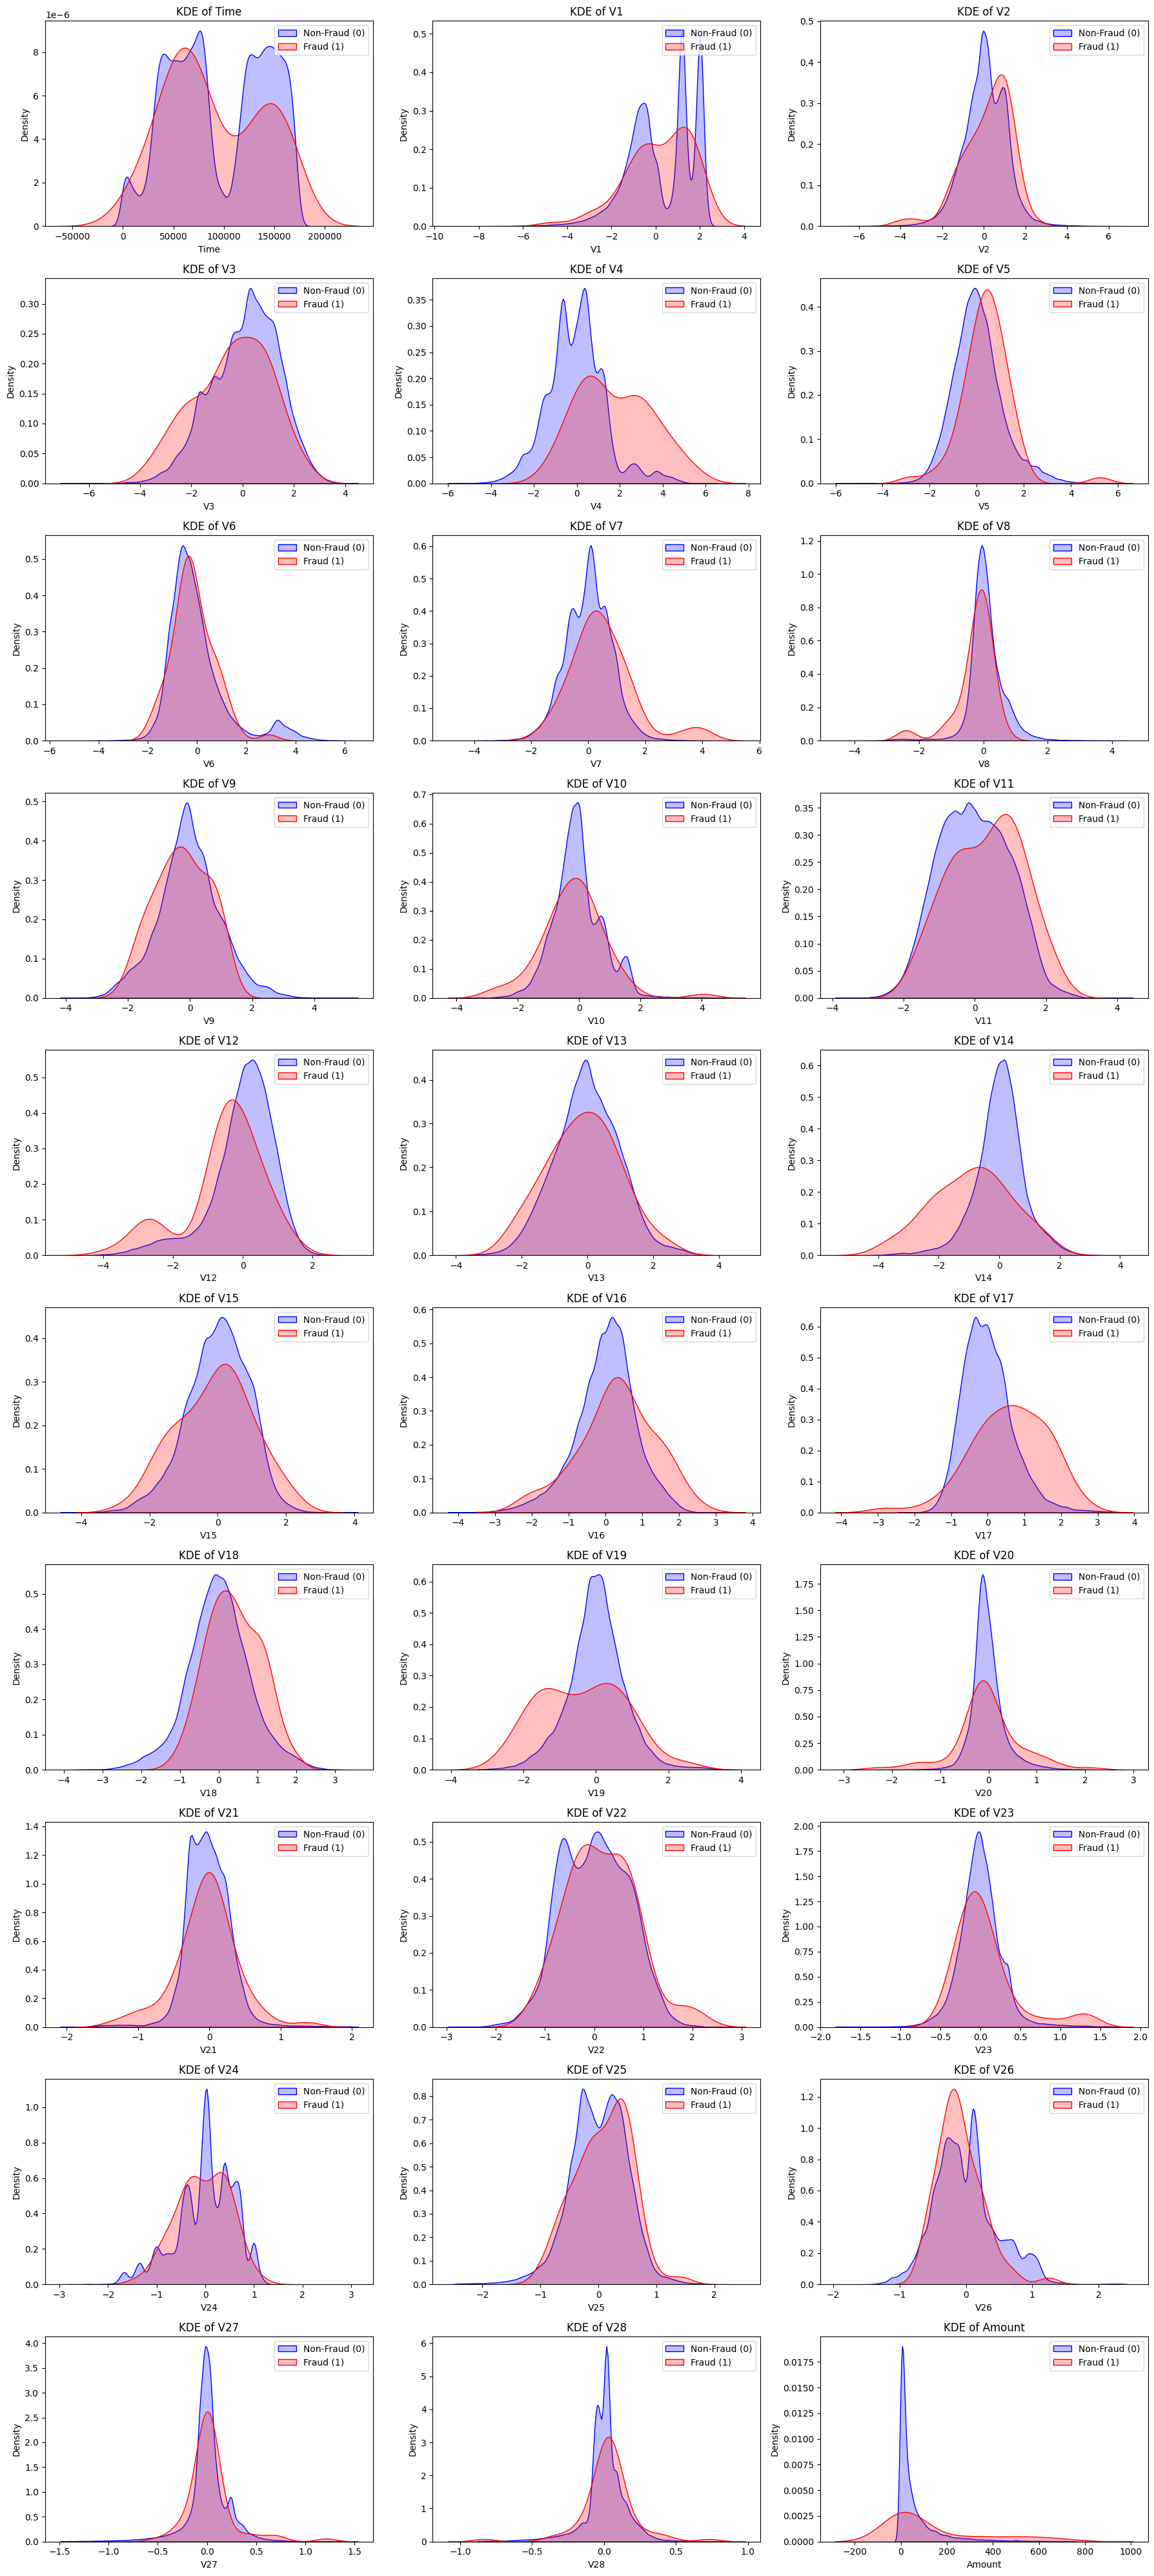

In [13]:
features = [col for col in df_clean.columns if col != 'Class']

# Split fraud and non-fraud
fraud = df_clean[df_clean['Class'] == 1]
non_fraud = df_clean[df_clean['Class'] == 0]

# Number of subplots
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols  # ceiling division

# Set up the plot
plt.figure(figsize=(6 * n_cols, 4 * n_rows))

# Plot KDEs
for i, feat in enumerate(features):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    sns.kdeplot(non_fraud[feat], label='Non-Fraud (0)', color='blue', fill=True, common_norm=False)
    sns.kdeplot(fraud[feat], label='Fraud (1)', color='red', fill=True, common_norm=False)
    ax.set_title(f'KDE of {feat}')
    ax.legend()

plt.tight_layout()

We see that now the data look more reasonable. But we don't really know if it's good or not, we will check when modeling.

# Training

We will create a test dataset first.

Then we will clean outliers and see if this helps for a baseline model to see if we need to proceed with this approach further.

In [14]:
X = df.drop(columns = ['Class'])
y = df['Class']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify=y)

In [16]:
df_train = pd.concat([X_train, y_train], axis=1)

In [17]:
df_train_clean = df_train.copy()

for feat in features:
    std = df_train_clean[feat].std()
    df_train_clean = df_train_clean[
        (df_train_clean[feat] < df_train_clean[feat].mean() + sigma_threshold * std) 
        & (df_train_clean[feat] > df_train_clean[feat].mean() - sigma_threshold * std)
        ]

In [18]:
x_train_clean = df_train_clean.drop(columns = ['Class'])
y_train_clean = df_train_clean['Class']

In [19]:
%%time
model_rf = RF(n_estimators=100 , n_jobs = -1)
model_rf.fit(X_train, y_train)

CPU times: user 13min 25s, sys: 11.4 s, total: 13min 36s
Wall time: 2min 14s


RandomForestClassifier(n_jobs=-1)

# Inference

In [20]:
# Make predictions
y_pred_rf = model_rf.predict(X_test)

# Postprocessing

In [21]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



# Training

In [22]:
model_rf = RF(n_estimators=100 , n_jobs = -1)
model_rf.fit(x_train_clean, y_train_clean)

RandomForestClassifier(n_jobs=-1)

# Inference

In [23]:
# Make predictions
y_pred_rf_clean = model_rf.predict(X_test)

# Postprocessing

In [24]:
print(classification_report(y_test, y_pred_rf_clean))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.58      0.18      0.28        98

    accuracy                           1.00     56962
   macro avg       0.79      0.59      0.64     56962
weighted avg       1.00      1.00      1.00     56962



We see that the values are NOT outliers, but rather good predictors, so we do NOT need to clean them.

# Preprocessing

# Upsampling

In [25]:
# Split majority and minority classes
majority = df_train[df_train["Class"] == 0]
minority = df_train[df_train["Class"] == 1]

# Upsample minority class
minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

# Training

In [26]:
# Combine to get balanced training data
train_balanced = pd.concat([majority, minority_upsampled])
X_train_bal = train_balanced.drop("Class", axis=1)
y_train_bal = train_balanced["Class"]

In [27]:
# Train model
model = RF(n_estimators=100, random_state=42)
model.fit(X_train_bal, y_train_bal)

RandomForestClassifier(random_state=42)

# Inference

In [28]:
# Predict and evaluate on original test set
y_pred_rf_bal = model.predict(X_test)

# Postprocessing

In [29]:
print(classification_report(y_test, y_pred_rf_bal))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.78      0.86        98

    accuracy                           1.00     56962
   macro avg       0.98      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



We see that upsamling does not give much, even a little worse score, so we will use the original dataset.

# Gradient Boosting

## Training

In [30]:
def objective(trial):
    np.random.seed(42)

    # Hyperparameter search space
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "depth": trial.suggest_int("depth", 3, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 0.5, 5.0),
        "iterations": 1000,
        "loss_function": "Logloss",
        "eval_metric": "F1",
        "verbose": 0
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1_scores = []
    best_iterations = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        x_tr, x_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = CatBoostClassifier(**params, random_seed=42)

        model.fit(
            x_tr, y_tr,
            eval_set=(x_val, y_val),
            early_stopping_rounds=100,
            use_best_model=True
        )

        y_pred = model.predict(x_val)
        f1 = f1_score(y_val, y_pred, average='macro')
        f1_scores.append(f1)
        best_iterations.append(model.get_best_iteration())

    # Save average best iteration across folds
    avg_best_iter = int(np.mean(best_iterations))
    trial.set_user_attr("best_iteration", avg_best_iter)

    return np.mean(f1_scores)

In [31]:
# Step 2: Run the Optuna study
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=10)

# Step 4: Train final model on full x_train with best parameters
best_params = study.best_trial.params

[I 2026-03-04 16:41:41,748] A new study created in memory with name: no-name-5b74990e-9e27-4a5e-9a97-56ed3a214b1b
[I 2026-03-04 16:42:03,926] Trial 0 finished with value: 0.9303448163875979 and parameters: {'learning_rate': 0.08116262258099886, 'depth': 8, 'l2_leaf_reg': 3.793972738151323}. Best is trial 0 with value: 0.9303448163875979.
[I 2026-03-04 16:42:36,896] Trial 1 finished with value: 0.9290058375936362 and parameters: {'learning_rate': 0.12374511199743694, 'depth': 3, 'l2_leaf_reg': 1.201975341512912}. Best is trial 0 with value: 0.9303448163875979.
[I 2026-03-04 16:43:27,727] Trial 2 finished with value: 0.9269648524792548 and parameters: {'learning_rate': 0.021035886311957897, 'depth': 8, 'l2_leaf_reg': 3.20501755284444}. Best is trial 0 with value: 0.9303448163875979.
[I 2026-03-04 16:43:54,106] Trial 3 finished with value: 0.9298319030582304 and parameters: {'learning_rate': 0.14453378978124864, 'depth': 3, 'l2_leaf_reg': 4.864594334728975}. Best is trial 0 with value: 0.

In [32]:
best_trial = study.best_trial
print("Best F1 score:", best_trial.value)
print("Best iteration (trees):", best_trial.user_attrs["best_iteration"])

Best F1 score: 0.9335036732201081
Best iteration (trees): 162


In [33]:
best_params.update({
    "iterations": best_trial.user_attrs["best_iteration"],
    "verbose": 0
})

In [34]:
final_model = CatBoostClassifier(**best_params)
final_model.fit(X_train, y_train)

## Inference

In [35]:
# Step 5: Predict on x_test and evaluate
y_pred_gb = final_model.predict(X_test)

# Postprocessing

In [36]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.96      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



We see that we did not outperform Random Forest. For the sake of time, we tuned only for 10 iterations but we need at least 100, so Gradient Boosting might do better. Also, seems we are overfitting even with cross validation, so better regularization might need to be done.

# Conclusions

- We see that we are able to make quite good predictions with a Baseline Model.
- Since we do not know the meaning of variables, it's hard to perform feature engineering on this dataset. However, some experimentatio still could be done.
- Upsampling made our predictions worse.
- The values which seemed outliers in the beginning are actually good predictors, so we kept them.
- For deployment, we can proceed with Random Forest and then improve if required.